# IVS Weekmonitor Analysis & UN/LOCODE Mapping

This notebook demonstrates how to process the IVS weekmonitor data from Rijkswaterstaat, aggregate cargo by origin-destination (OD) pairs, and map these flows to the inland waterway network using ISRS locodes and Zenodo reference data.

In [1]:
import pathlib
import zipfile
import io
import requests
import pickle
import itertools
import logging

import pandas as pd
import geopandas as gpd
import shapely.wkt
import shapely.geometry
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx

# Set up logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

## 1. Load IVS Data Directly from Internet
We fetch the latest weekmonitor ZIP and read the CSV content in-memory.

In [2]:
ivs_url = "https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip"

logger.info(f"Fetching IVS data from {ivs_url}...")
r = requests.get(ivs_url, timeout=30)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        ivs_df = pd.read_csv(f, sep=";")

logger.info(f"Loaded {len(ivs_df)} records from {csv_filename}.")
ivs_df.head()

INFO: Fetching IVS data from https://downloads.rijkswaterstaatdata.nl/scheepvaart/goederenvervoer/archief/IVS_weekmonitor_31MAR2026_20260401_051939.zip...


INFO: Loaded 55646 records from IVS_weekmonitor_31MAR2026.csv.


,Jaarmaand,Jaar,Maand,Weeknr,v05_06_Begindt_evenement_iso,v05_06_Begindt_evenement,UNLO_herkomst,UNLO_bestemming,v15_1_Scheepstype_RWS,SK_CODE,v18_Laadvermogen,v28_Beladingscode,v38_Vervoerd_gewicht,v30_4_Containers_TEU_S,nstr_nw,nst2007_nw
0,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,DEFRA,2,M8,2660,7,1303000.0,0,3.0,7.2
1,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEANR,NLAMS,2,M8,3550,7,1030000.0,0,3.0,8.5
2,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLLEY,NLUTC,1,M8,3230,7,514125.0,65,9.0,19.2
3,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,NLAMS,FRSXB,2,M9,3500,7,2122000.0,0,3.0,7.2
4,2602,2026,2,5,2026-02-01T00:00:00+01:00,01 februari 2026 00:00:00 uur,BEGNE,BEANR,2,M10,5220,7,2704000.0,0,8.0,8.2


## 2. Aggregate OD Data
We group the cargo data by origin (`UNLO_herkomst`) and destination (`UNLO_bestemming`).

In [3]:
# Aggregate transported weight (v38_Vervoerd_gewicht) by OD pair
od_pairs = (
    ivs_df.groupby(["UNLO_herkomst", "UNLO_bestemming"])["v38_Vervoerd_gewicht"]
    .sum()
    .reset_index()
)
od_pairs = od_pairs.sort_values(by="v38_Vervoerd_gewicht", ascending=False)

logger.info("Top 5 OD Pairs by Weight:")
for idx, row in od_pairs.head(5).iterrows():
    logger.info(
        f"  {row['UNLO_herkomst']} -> {row['UNLO_bestemming']}: {row['v38_Vervoerd_gewicht']:,} kg"
    )

INFO: Top 5 OD Pairs by Weight:


INFO:   NLRTM -> BEANR: 2,665,403,602.0 kg


INFO:   NLRTM -> DESGW: 2,441,593,359.0 kg


INFO:   NLRTM -> NLAMS: 1,613,742,622.0 kg


INFO:   BEANR -> NLRTM: 1,429,370,301.0 kg


INFO:   NLRTM -> DEDHU: 1,334,228,000.0 kg


## 3. Load Network and Map UN/LOCODEs
We load the merged graph and map the 5-character UN/LOCODEs to network nodes (specifically `sectionjunction` types).

In [4]:
graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

nodes_gdf = gpd.GeoDataFrame(graph.nodes.values(), index=graph.nodes.keys())
# Ensure CRS is set (fail-fast)
nodes_gdf = nodes_gdf.set_crs(epsg=4326)

logger.info(f"Loaded network with {len(nodes_gdf)} nodes.")


def find_nodes_for_locode(locode):
    """Find network nodes matching the given 5-char UN/LOCODE, focusing on sectionjunctions."""
    # Match by prefix or inclusion in ISRS locode
    mask = nodes_gdf["locode"].str.startswith(locode, na=False) | nodes_gdf[
        "locode"
    ].str.contains(locode[2:], na=False)

    # Focus on sectionjunction nodes
    junction_mask = nodes_gdf["geo_type"] == "sectionjunction"

    nodes = nodes_gdf[mask & junction_mask]
    assert not nodes.empty, f"No sectionjunction nodes found for {locode}"
    return nodes


# Example: Rotterdam (NLRTM) to Antwerp (BEANR)
origin_locode = "NLRTM"
dest_locode = "BEANR"

origin_nodes = find_nodes_for_locode(origin_locode)
dest_nodes = find_nodes_for_locode(dest_locode)

logger.info(f"Found {len(origin_nodes)} sectionjunction nodes for {origin_locode}")
logger.info(f"Found {len(dest_nodes)} sectionjunction nodes for {dest_locode}")

INFO: Loaded network with 7089 nodes.


INFO: Found 323 sectionjunction nodes for NLRTM


INFO: Found 1 sectionjunction nodes for BEANR


## 4. Reference Data: Zenodo Geocoded UN/LOCODEs
We use the geocoded dataset as a coordinate fallback for locations missing in the physical network.

In [5]:
zenodo_url = (
    "https://zenodo.org/records/11191511/files/unlo-geocoded-v0.1.gpkg?download=1"
)
zenodo_local = pathlib.Path("unlo-geocoded-v0.1.gpkg")

if not zenodo_local.exists():
    logger.info(f"Downloading Zenodo reference data to {zenodo_local}...")
    r = requests.get(zenodo_url, timeout=60)
    r.raise_for_status()
    zenodo_local.write_bytes(r.content)

zenodo_gdf = gpd.read_file(zenodo_local)
logger.info(f"Loaded {len(zenodo_gdf)} geocoded locations.")

# Lookup Rotterdam
rtm_ref = zenodo_gdf[
    (zenodo_gdf["country_code"] == "NL") & (zenodo_gdf["location_code"] == "RTM")
]
assert not rtm_ref.empty, "Rotterdam (NLRTM) not found in Zenodo data"
logger.info(
    f"Zenodo Reference for Rotterdam: {rtm_ref.iloc[0]['name']} at {rtm_ref.geometry.iloc[0]}"
)

INFO: Downloading Zenodo reference data to unlo-geocoded-v0.1.gpkg...


INFO: Loaded 116432 geocoded locations.


INFO: Zenodo Reference for Rotterdam: Rotterdam at POINT (4.5 51.916666666666664)


## 5. Route and Visualize
Compute the shortest path between the first matching sectionjunction nodes and visualize with a background map.

INFO: Computing path from FIS_8867170 to FIS_35228495...


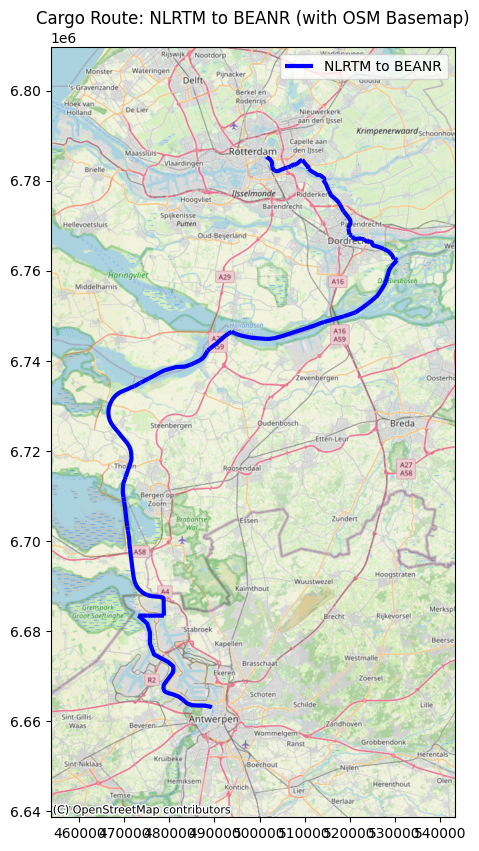

In [6]:
# Pick first matching node
start_node_id = origin_nodes.index[0]
end_node_id = dest_nodes.index[0]

logger.info(f"Computing path from {start_node_id} to {end_node_id}...")
route = nx.shortest_path(graph, start_node_id, end_node_id, weight="length_m")

# Extract geometries for visualization
geoms = []
for u, v in itertools.pairwise(route):
    edge_data = graph.edges[u, v]
    geom = edge_data.get("geometry")
    if isinstance(geom, str):
        geom = shapely.wkt.loads(geom)
    if geom:
        geoms.append(geom)

route_gdf = gpd.GeoDataFrame(geometry=geoms, crs="EPSG:4326")
assert not route_gdf.empty, "No geometries found for the computed route"

# Convert to Web Mercator for contextily
route_3857 = route_gdf.to_crs(epsg=3857)
nodes_3857 = nodes_gdf.to_crs(epsg=3857)

# Simple plot
fig, ax = plt.subplots(figsize=(12, 10))
nodes_3857.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.3)
route_3857.plot(
    ax=ax,
    color="blue",
    linewidth=3,
    label=f"{origin_locode} to {dest_locode}",
)

# Zoom into the route with a 20% buffer
minx, miny, maxx, maxy = route_3857.total_bounds
dx = maxx - minx
dy = maxy - miny
ax.set_xlim(minx - 0.2 * dx, maxx + 0.2 * dx)
ax.set_ylim(miny - 0.2 * dy, maxy + 0.2 * dy)

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"Cargo Route: {origin_locode} to {dest_locode} (with OSM Basemap)")
plt.legend()
plt.show()